# InternSpark Task 1 — Supervised Classification

**Project:** Breast Cancer Wisconsin Classification  
**Algorithms:** Logistic Regression and Random Forest


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay


## 1. Load dataset
The dataset is included with scikit-learn, so no external download is required.

In [2]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print("Shape:", X.shape)
print("Classes:", list(data.target_names))
X.head()


Shape: (569, 30)
Classes: [np.str_('malignant'), np.str_('benign')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Data inspection

In [3]:
print("Missing values:", X.isna().sum().sum())
print("\nClass distribution:")
print(y.value_counts().sort_index())


Missing values: 0

Class distribution:
target
0    212
1    357
Name: count, dtype: int64


## 3. Train/test split
We use an 80/20 stratified split.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(len(X_train), "training samples")
print(len(X_test), "testing samples")


455 training samples
114 testing samples


## 4. Define two algorithms
Logistic Regression is used as a baseline. Random Forest provides a nonlinear ensemble comparison.

In [5]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=5000, random_state=42))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced"
    )
}


## 5. 5-fold cross-validation

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    print(f"{name}: mean={scores.mean():.4f}, std={scores.std():.4f}")


Logistic Regression: mean=0.9780, std=0.0098


Random Forest: mean=0.9626, std=0.0164


## 6. Train and evaluate

In [7]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })
results_df = pd.DataFrame(results).round(4)
results_df


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
1,Random Forest,0.9474,0.9583,0.9583,0.9583,0.9937


## 7. Detailed reports and confusion matrices

In [8]:
for name, model in models.items():
    pred = model.predict(X_test)
    print("\n", "="*50, "\n", name)
    print(classification_report(y_test, pred, target_names=data.target_names))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))



 Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Confusion matrix:
 [[41  1]
 [ 1 71]]

 Random Forest
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        42
      benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Confusion matrix:
 [[39  3]
 [ 3 69]]


## 8. ROC curves

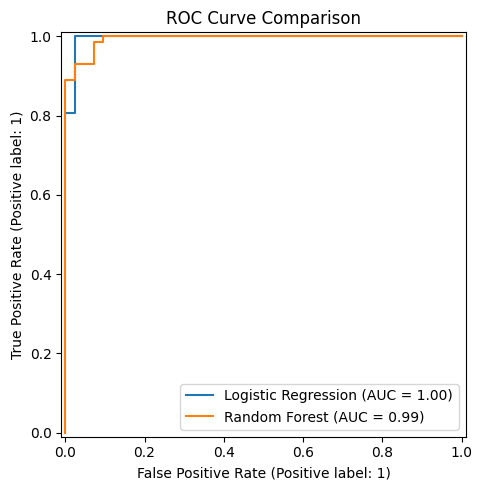

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()


## 9. Final comparison
Select the best model by considering all metrics and cross-validation stability.

In [10]:
print(results_df.sort_values("ROC-AUC", ascending=False))


                 Model  Accuracy  Precision  Recall      F1  ROC-AUC
0  Logistic Regression    0.9825     0.9861  0.9861  0.9861   0.9954
1        Random Forest    0.9474     0.9583  0.9583  0.9583   0.9937


## Conclusion
Both models were trained and compared. The complete evaluation is documented above, including accuracy, precision, recall, F1, ROC-AUC, confusion matrices, and ROC curves.